In [29]:
#!/usr/bin/env python3
import getopt
import os
import sys
import re
import time
import numpy as np
import datetime as dt
import argparse
import shutil
import daz_lib_licsar as dl
from lics_unwrap import *


In [3]:
def loadall2cube(cumfile, extracols=['loop_ph_avg_abs']):
    cumdir = os.path.dirname(cumfile)
    cohfile = os.path.join(cumdir,'results/coh_avg')
    rmsfile = os.path.join(cumdir,'results/resid_rms')
    vstdfile = os.path.join(cumdir,'results/vstd')
    stcfile = os.path.join(cumdir,'results/stc')
    maskfile = os.path.join(cumdir,'results/mask')
    metafile = os.path.join(cumdir,'../../metadata.txt')
    #h5datafile = 'cum.h5'
    cum = xr.load_dataset(cumfile)
    
    sizex = len(cum.vel[0])
    sizey = len(cum.vel)
    
    lon = cum.corner_lon.values+cum.post_lon.values*np.arange(sizex)-0.5*float(cum.post_lon)
    lat = cum.corner_lat.values+cum.post_lat.values*np.arange(sizey)+0.5*float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
    
    time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
    
    velxr = xr.DataArray(cum.vel.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    #LiCSBAS uses 0 instead of nans...
    velxr = velxr.where(velxr!=0)
    velxr.attrs['unit'] = 'mm/year'
    #vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    
    cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time","lat", "lon"])
    cumxr.attrs['unit'] = 'mm'
    #bperpxr = xr.DataArray(cum.bperp.values, coords=[time], dims=["time"])
    
    cube = xr.Dataset()
    cube['cum'] = cumxr
    cube['vel'] = velxr
    
    # Load Ionospheric correction (iono) from cum.h5 if it exists
    if 'iono' in cum:
        ionoxr = xr.DataArray(cum.iono.values.reshape(cum.cum.shape), 
                              coords=[time, lat, lon], dims=["time", "lat", "lon"])
        ionoxr = ionoxr.where(ionoxr != 0)  # Replace zeros with NaNs
        ionoxr.attrs['unit'] = 'mm'
        cube['iono'] = ionoxr
    else:
        print('No iono data found in cum.h5, skipping')

    # Load Solid Earth Tides correction (tide) from cum.h5 if it exists
    if 'tide' in cum:
        tidexr = xr.DataArray(cum.tide.values.reshape(cum.cum.shape), 
                              coords=[time, lat, lon], dims=["time", "lat", "lon"])
        tidexr = tidexr.where(tidexr != 0)  # Replace zeros with NaNs
        tidexr.attrs['unit'] = 'mm'
        cube['tide'] = tidexr
    else:
        print('No tide data found in cum.h5, skipping')

    ###
    # Load Solid Earth Tides correction (tide) from cum.h5 if it exists
    if 'cum_abs' in cum:
        cum_abs = xr.DataArray(cum.cum_abs.values, coords=[time, lat, lon], dims=["time", "lat", "lon"])
        # cum_abs = cum_abs.where(cum_abs != 0)  # Replace zeros with NaNs
        cum_abs.attrs['unit'] = 'mm'
        cube['cum_abs'] = cum_abs
    else:
        print('No cum_abs data found in cum.h5, skipping')
    ###
    #cube['vintercept'] = vinterceptxr
    try:
        cube['bperp'] = xr.DataArray(cum.bperp.values, coords=[time], dims=["time"])
        cube['bperp'] = cube.bperp.where(cube.bperp!=0)
        # re-ref it to the first date
        if np.isnan(cube['bperp'][0]):
            firstbperp = 0
        else:
            firstbperp = cube['bperp'][0]
        cube['bperp'] = cube['bperp'] - firstbperp
        cube['bperp'] = cube.bperp.astype(np.float32)
        cube.bperp.attrs['unit'] = 'm'
    except:
        print('some error loading bperp info')
    
    #if 'mask' in cum:
    #    # means this is filtered version, i.e. cum_filt.h5
    cube.attrs['filtered_version'] = 'mask' in cum
    
    #add coh_avg resid_rms vstd
    if os.path.exists(cohfile):
        infile = np.fromfile(cohfile, 'float32')
        cohxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        cube['coh'] = cohxr
        cube.coh.attrs['unit']='unitless'
    else: print('No coh_avg file detected, skipping')
    if os.path.exists(rmsfile):
        infile = np.fromfile(rmsfile, 'float32')
        rmsxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        rmsxr.attrs['unit'] = 'mm'
        cube['rms'] = rmsxr
    else: print('No RMS file detected, skipping')
    try:
        for e in extracols:
            efile=os.path.join(cumdir,'results',e)
            if os.path.exists(efile):
                infile = np.fromfile(efile, 'float32')   # should be always float. but we can check with os.stat('loop_ph_avg_abs').st_size
                exr = xr.DataArray(infile.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
                #rmsxr.attrs['unit'] = 'mm'
                cube[e] = exr
            else:
                print('No '+e+' file detected, skipping')
    except:
        print('debug - extra layers not included')
    if os.path.exists(vstdfile):
        infile = np.fromfile(vstdfile, 'float32')
        vstdxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        vstdxr.attrs['unit'] = 'mm/year'
        cube['vstd'] = vstdxr
    else: print('No vstd file detected, skipping')
    if os.path.exists(stcfile):
        infile = np.fromfile(stcfile, 'float32')
        stcxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        stcxr.attrs['unit'] = 'mm'
        cube['stc'] = stcxr
    else: print('No stc file detected, skipping')
    if os.path.exists(maskfile):
        infile = np.fromfile(maskfile, 'float32')
        #infile = np.nan_to_num(infile,0).astype(int)  # change nans to 0
        infile = np.nan_to_num(infile,0).astype(np.int8)  # change nans to 0
        maskxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        maskxr.attrs['unit'] = 'unitless'
        cube['mask'] = maskxr
    else: print('No mask file detected, skipping')
    # add inc_angle
    if os.path.exists(metafile):
        #a = subp.run(['grep','inc_angle', metafile], stdout=subp.PIPE)
        #inc_angle = float(a.stdout.decode('utf-8').split('=')[1])
        inc_angle = float(grep1line('inc_angle',metafile).split('=')[1])
        cube.attrs['inc_angle'] = inc_angle
    else: print('')#'warning, metadata file not found. using general inc angle value')
        #inc_angle = 39
    
    #cube['bperp'] = bperpxr
    #cube[]
    cube.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    cube.rio.write_crs("EPSG:4326", inplace=True)
    cube = cube.sortby(['time','lon','lat'])
    return cube

In [30]:
tsadir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525/TS_GEOCml10'
framedir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525'
frame=os.path.basename(framedir)
cumfile=os.path.join(tsadir,'cum.h5')


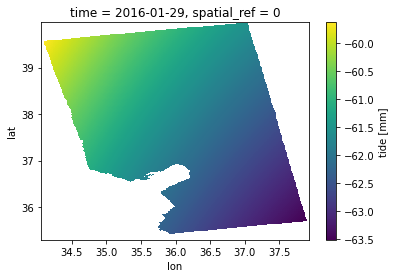

In [10]:
cube.tide[1].plot()

In [11]:
first_date = cube.time.isel(time=0).values.astype(str).split('T')[0]
cube['cum'] = cube['cum'] - cube['cum'].sel(time=first_date)

# Create DataFrame from cube time steps
df_cube = pd.DataFrame({'epoch': pd.to_datetime(cube['time'].values)})

# Load azimuth ionospheric delay (daz) from frame 
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000 ## convert mm

# Merge and interpolate 
df_merged = pd.merge(df_cube, dazes, on='epoch', how='left')       # Keep all epochs from cube
df_merged = df_merged.sort_values(by='epoch')                      # Ensure order
df_merged['daz'] = df_merged['daz'].interpolate(method='nearest', limit_direction='both')                      # Fill nan daz values

# Convert merged DataFrame to xarray format
df_merged_xr = df_merged.set_index("epoch").to_xarray()

# Align the daz column with the cube dataset based on the 'time' dimension
cube = cube.assign(
    daz=("time", df_merged_xr.daz.reindex(time=cube["time"], method="nearest").data)
)
# Display the updated cube dataset
cube['daz'] = cube['daz'] - cube['daz'].sel(time=first_date)
cube['cum_absolute']=cube['cum']+cube['daz']

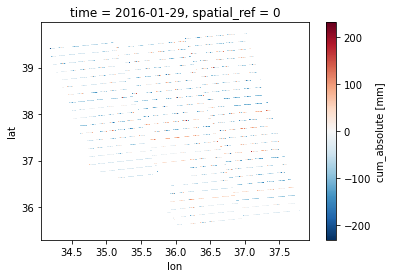

In [13]:
cube.cum_absolute[1].plot()

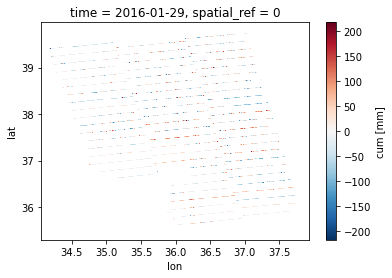

In [14]:
cube.cum[1].plot()

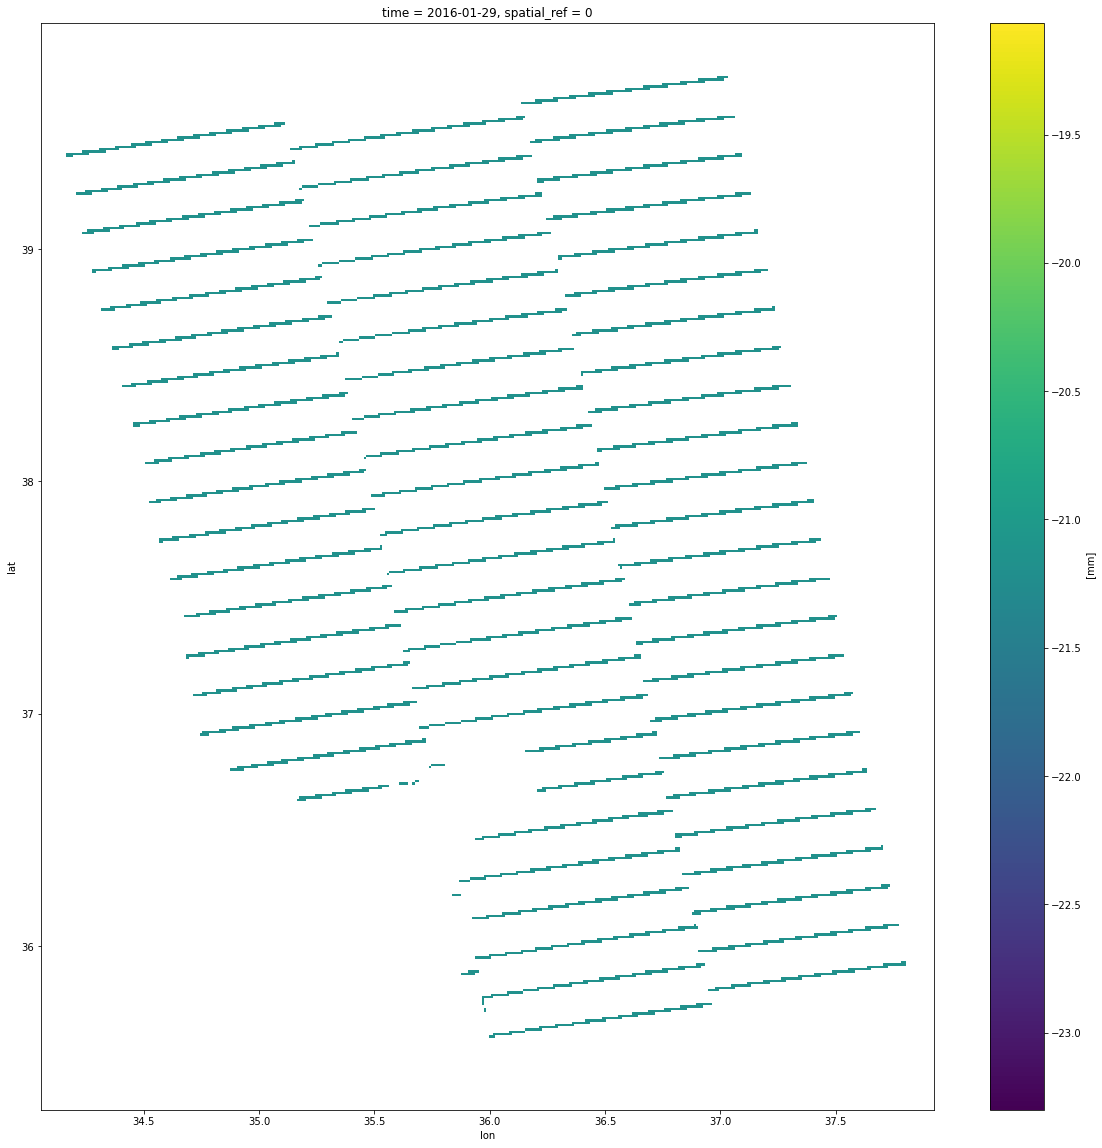

In [16]:
(cube.cum_absolute[1]-cube.cum[1]).plot(figsize=(20,20))

In [24]:
df_merged

,epoch,daz
0,2016-01-05,-98.379680
1,2016-01-29,-119.561820
2,2016-02-22,-80.578120
3,2016-03-05,-59.610180
4,2016-03-17,-149.759400
...,...,...
357,2022-11-05,-47.779200
358,2022-11-17,-9.039506
359,2022-11-29,0.335807
360,2022-12-11,-7.650874


In [20]:
np.nanmax((cube.cum_absolute[1]-cube.cum[1]).values)

-21.18213999999999

In [21]:
np.nanmin((cube.cum_absolute[1]-cube.cum[1]).values)

-21.182140000000004

In [22]:
np.nanmedian((cube.cum_absolute[1]-cube.cum[1]).values)

-21.18213999999999

In [25]:
cube['daz']

<xarray.DataArray 'daz' (time: 362)>
array([   0.       ,  -21.18214  ,   17.80156  ,   38.7695   ,
        -51.37972  ,   -1.80096  ,    5.46406  ,   48.34564  ,
        -21.98196  ,  -54.53952  ,  -63.68012  ,  -14.99974  ,
         62.67996  ,   20.54626  ,  -34.75402  ,    8.2187   ,
         -2.66476  ,   23.64936  ,  -56.10612  ,   41.73596  ,
        -31.26718  ,   -8.4637   ,   44.32918  ,    1.16746  ,
         37.58146  ,    4.08744  ,  -13.10106  ,    6.20788  ,
         14.87038  ,   34.52666  ,   58.32904  ,  -12.586    ,
         84.30674  ,   47.70528  ,   18.97098  ,   12.01998  ,
         76.88716  ,   -3.00888  ,  -85.35912  ,   10.36266  ,
         45.93876  ,   39.67838  ,    6.27242  ,   36.9271   ,
         75.86026  ,   22.06456  ,   41.48606  ,   99.2897598,
        -22.73222  ,   63.3458   ,   50.53104  ,   82.00234  ,
         22.95496  ,   25.23234  ,   42.24584  ,   58.36082  ,
         54.12554  ,   24.10072  ,   43.70058  ,   62.4001   ,
        -23.0664   ,   10.71196  ,   26.62324  ,   39.59564  ,
         82.91416  , -114.33912  ,   19.72054  ,   67.70162  ,
         22.862    ,   37.34486  ,   31.26564  ,   88.788574 ,
        -17.98496  ,   30.33548  ,  -18.2042   ,   50.51592  ,
         14.42504  ,    2.35718  ,   -3.74906  ,   13.49964  ,
...
         95.371612 ,  110.154492 ,   92.450274 ,   87.421194 ,
         60.08996  ,   75.58936  ,  112.232498 ,   51.1504   ,
         24.89018  ,   87.037888 ,  120.08738  ,  105.78715  ,
         89.578062 ,   97.0318608,  103.344696 ,   55.42404  ,
        101.720038 ,  123.98288  ,   29.21604  ,  155.6695   ,
         42.29876  ,   96.022346 ,   96.814368 ,   73.55894  ,
         55.60506  ,   74.6368   ,  149.13626  ,  104.867378 ,
         77.73374  ,   39.08114  ,  136.93148  ,   64.56926  ,
         87.781372 ,   44.04442  ,  124.44796  ,  139.42138  ,
        146.64734  ,   97.157844 ,  135.83556  ,  114.83808  ,
        174.94778  ,   49.55328  ,   91.613312 ,   96.78354  ,
        150.94702  ,   49.18998  ,   94.843868 ,  170.26198  ,
         42.2534   ,   73.53094  ,   71.56548  ,  138.6966   ,
        131.21542  ,  135.59658  ,  130.704    ,  133.301    ,
        100.156882 ,   44.81526  ,   94.78924  ,  104.753362 ,
         67.8594   ,  143.63286  ,   94.276294 ,   67.65612  ,
         25.13798  ,   88.442662 ,  112.73864  ,   83.20228  ,
         69.7536   ,   69.7536   ,   78.25454  ,   89.806668 ,
        139.68668  ,   50.60048  ,   89.340174 ,   98.7154868,
         90.728806 ,  161.32732  ])
Coordinates:
  * time         (time) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
    spatial_ref  int64 0

In [27]:
cum_abs = cube['cum_absolute'].values.astype('float32')

In [28]:
cum_abs

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       ..., 
       [[ nan,  nan, 

In [26]:
with h5.File(cumfile, 'r+') as hf:
    if 'cum_abs' in hf:
        del hf['cum_abs']
    hf.create_dataset('cum_abs', data=cube['cum_absolute'].values.astype('float32'))


RuntimeError: Disable slist on flush dest failure failed (file write failed: time = Mon Mar 24 21:05:05 2025
, filename = '/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525/TS_GEOCml10/cum.h5', file descriptor = 62, errno = 5, error message = 'Input/output error', buf = 0x5631fa3b6be0, total write size = 268, bytes this sub-write = 268, bytes actually written = 18446744073709551615, offset = 0)